Analysing data for Mark


In [40]:
%matplotlib inline
import numpy as np
from uncertainties import ufloat
from uncertainties import umath
import matplotlib.pyplot as plt
from scipy import optimize, interpolate
from scipy.special import erf
from scipy.optimize import minimize
import scipy.integrate as integrate

from astropy import stats
import pickle
import stand_pol_i as stand_pol

In [41]:
class star:
    def __init__(self ,PD, PDerr, PA, PAerr):
        self.PD    = PD        # in %
        self.PDerr = PDerr
        self.PA    = PA        # in deg
        self.PAerr = PAerr


In [42]:
class Obs():
    def __init__(self,name,JD,q,qerr,u,uerr,x=0.0,y=0.0,R=0,Rerr=0):
        self.name = name
        self.JD   = JD
        self.q    = ufloat(q,qerr)
        self.u    = ufloat(u,uerr)
        self.x    = x
        self.y    = y
        self.R    = R
        self.Rerr = Rerr
        self.Acorr = 0.033
        self.Flux = ufloat(0.0,0.0)

    def getP(self):
        return umath.sqrt(self.q ** 2 + self.u ** 2)

    def getPA(self):
        PAval = 0.5*umath.atan2(self.u,self.q)
        PAunc = self.getSigma(self.getP().n,self.getP().s)
        return ufloat(np.degrees(PAval.n),np.degrees(PAunc))
    
    def getF(self):
        magR = ufloat(self.R - self.Acorr,self.Rerr)
        self.Flux = 10**(6.489 - 0.4 * magR) # Mead et al. 1990
        return self.Flux
    
    def getCorrR(self,Flux):
        magR = (6.489-umath.log10(Flux))/0.4
        return magR
    
    def correctInst(self,q_inst,u_inst):
        self.q = self.q - q_inst
        self.u = self.u - u_inst
    
    def correctRot(self,dPA):
        THETA = umath.radians(dPA)
        Qnew = self.q * umath.cos(2*THETA) - self.u * umath.sin(2*THETA)
        Unew = self.q * umath.sin(2*THETA) + self.u * umath.cos(2*THETA)
        self.q = Qnew
        self.u = Unew
        
    def EVPA_pdf(self,theta,P0):
        """
        EVPA measurements are also non-Gaussian and defined by the following
        probability density (Naghizadeh-Khouei & Clarke 1993):
        """
        g = 1/np.sqrt(np.pi)
        ita0 = float(P0)/np.sqrt(2) * np.cos(2 * theta)
        g = g * (g + ita0 * np.exp(ita0**2) * (1 + erf(ita0)))
        g = g * np.exp(-(float(P0)**2)/2)
        return g
    
    def int_eq(self,sigma,snr):
        """ This is the integral of EVPA probability density from -sigma to sigma """
        integ = integrate.quad(lambda x: self.EVPA_pdf(x,snr),-sigma,sigma)
        return abs(integ[0] - 0.68268949)
    
    def getSigma(self,pd,pd_err):
        snr = pd/pd_err
        if snr > 20:
            # it is a good approximation even for snr = 5
            return 0.5*1.0/float(snr)

        if snr < np.sqrt(2.0):
            pd = 0.0
        else:
            pd = np.sqrt(pd**2 - pd_err**2)

        snr = pd/pd_err

        res = minimize(self.int_eq, [np.pi/50], args=(snr,), method='Nelder-Mead', tol=1e-5) # np.pi/50 = 3.6 deg - just a reasonable guess
        if res.status != 0:
            print('Something is wrong with the EVPA uncertainty calculation:\n')
            return np.nan

        return res.x[0]

class Stand():
    def __init__(self, st):
        self.name = st
        stand = stand_pol.STANDARDS[self.name]
        self.PD    = ufloat(stand.PD/100., stand.PDerr/100.)
        self.PA    = ufloat(stand.PA, stand.PAerr)
        self.calcQU()

    def calcQU(self):
        self.q = self.PD * umath.cos( 2 * umath.radians(self.PA) )
        self.u = self.PD * umath.sin( 2 * umath.radians(self.PA) )

Raw processed data (no model):

In [43]:



o1 = Obs("BD+33.2642",2460830.54358,0.00415,0.00215,-0.00632,0.00211)
o2 = Obs("BD+33.2642",2460830.54377,0.00414,0.00213,-0.00560,0.00209)
o3 = Obs("BD+33.2642",2460830.54397,0.00681,0.00215,-0.00232,0.00210)
o4 = Obs("BD+33.2642",2460830.54417,0.00504,0.00217,-0.00383,0.00212)
o5 = Obs("BD+33.2642",2460830.54436,0.00125,0.00215,-0.00734,0.00210)
o6 = Obs("BD+33.2642",2460830.54456,0.00441,0.00214,0.00034,0.00209)
o7 = Obs("BD+33.2642",2460830.54476,0.00295,0.00218,-0.00468,0.00214)
o8 = Obs("BD+33.2642",2460830.54495,0.00077,0.00218,-0.00160,0.00213)
o9 = Obs("BD+33.2642",2460830.54516,-0.00028,0.00214,-0.00682,0.00209)
o10 = Obs("BD+33.2642",2460830.54536,0.00496,0.00215,-0.00468,0.00211)
o11 = Obs("BD+40.2704",2460830.27096,0.00360,0.00100,-0.00423,0.00098)
o12 = Obs("BD+40.2704",2460830.27206,0.00364,0.00101,-0.00631,0.00099)
o13 = Obs("BD+40.2704",2460830.27316,0.00399,0.00099,-0.00785,0.00098)
o14 = Obs("BD+40.2704",2460830.27426,0.00398,0.00099,-0.00262,0.00097)
o15 = Obs("BD+40.2704",2460830.27536,0.00299,0.00099,-0.00313,0.00097)
o16 = Obs("BD+40.2704",2460830.27646,0.00535,0.00099,-0.00565,0.00097)
o17 = Obs("BD+40.2704",2460830.27756,0.00649,0.00099,-0.00502,0.00097)
o18 = Obs("HD154892",2460830.55575,0.00465,0.00104,-0.00529,0.00102)
o19 = Obs("HD154892",2460830.55588,0.00523,0.00105,-0.00296,0.00103)
o20 = Obs("HD154892",2460830.55601,0.00674,0.00104,-0.00739,0.00102)
o21 = Obs("HD154892",2460830.55613,0.00561,0.00105,-0.00501,0.00102)
o22 = Obs("HD154892",2460830.55626,0.00239,0.00104,-0.00337,0.00102)
o23 = Obs("HD183143",2460830.56241,0.05869,0.00069,-0.00803,0.00068)
o24 = Obs("HD183143",2460830.56253,0.05820,0.00069,-0.00797,0.00068)
o25 = Obs("HD183143",2460830.56265,0.05885,0.00069,-0.00572,0.00068)
o26 = Obs("HD183143",2460830.56278,0.05800,0.00069,-0.00594,0.00068)
o27 = Obs("HD183143",2460830.56289,0.05857,0.00069,-0.00608,0.00068)


######################################### object ######################################### 


s1 = Obs("Mark_26", 2460829.35684, 0.00769,  0.00021, -0.00416,  0.00030)
s2 = Obs("Mark_76", 2460830.36228, 0.01244,  0.00087, -0.01428,  0.00091)
s3 = Obs("Mark_81", 2460830.38151, 0.00575,  0.00081, -0.00745,  0.00086)

/home/dima/.conda/envs/mark/lib/python3.11/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


In [44]:
# correct for deviations from zero for "zero-polarized" standards

zero_st = [o1,o2,o3,o4,o5,o6,o7,o8,o9,o10,o11,o12,o13,o14,o15,o16,o17,o18,
           o19,o20,o21,o22,o23,o24,o25,o26,o27]

for zs in zero_st:
    stand = Stand(zs.name)
    zs.q = zs.q - stand.q
    zs.u = zs.u - stand.u


All standards


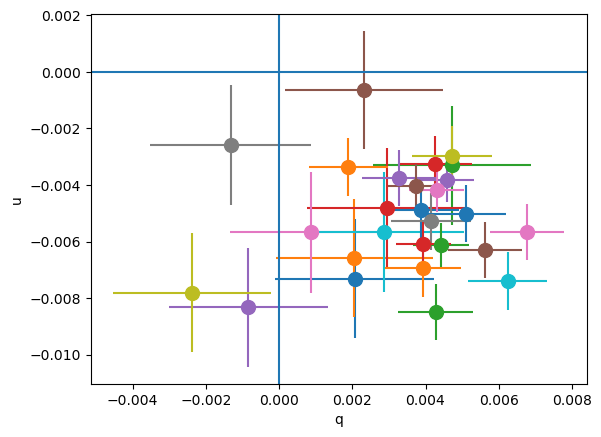

In [45]:
print("All standards")
plt.xlabel("q")
plt.ylabel("u")
plt.errorbar(o1.q.n,o1.u.n,xerr=o1.q.s,yerr=o1.u.s,fmt='.',markersize=20)
plt.errorbar(o2.q.n,o2.u.n,xerr=o2.q.s,yerr=o2.u.s,fmt='.',markersize=20)
plt.errorbar(o3.q.n,o3.u.n,xerr=o3.q.s,yerr=o3.u.s,fmt='.',markersize=20)
plt.errorbar(o4.q.n,o4.u.n,xerr=o4.q.s,yerr=o4.u.s,fmt='.',markersize=20)
plt.errorbar(o5.q.n,o5.u.n,xerr=o5.q.s,yerr=o5.u.s,fmt='.',markersize=20)
plt.errorbar(o6.q.n,o6.u.n,xerr=o6.q.s,yerr=o6.u.s,fmt='.',markersize=20)
plt.errorbar(o7.q.n,o7.u.n,xerr=o7.q.s,yerr=o7.u.s,fmt='.',markersize=20)
plt.errorbar(o8.q.n,o8.u.n,xerr=o8.q.s,yerr=o8.u.s,fmt='.',markersize=20)
plt.errorbar(o9.q.n,o9.u.n,xerr=o9.q.s,yerr=o9.u.s,fmt='.',markersize=20)
plt.errorbar(o10.q.n,o10.u.n,xerr=o10.q.s,yerr=o10.u.s,fmt='.',markersize=20)
plt.errorbar(o11.q.n,o11.u.n,xerr=o11.q.s,yerr=o11.u.s,fmt='.',markersize=20)
plt.errorbar(o12.q.n,o12.u.n,xerr=o12.q.s,yerr=o12.u.s,fmt='.',markersize=20)
plt.errorbar(o13.q.n,o13.u.n,xerr=o13.q.s,yerr=o13.u.s,fmt='.',markersize=20)
plt.errorbar(o14.q.n,o14.u.n,xerr=o14.q.s,yerr=o14.u.s,fmt='.',markersize=20)
plt.errorbar(o15.q.n,o15.u.n,xerr=o15.q.s,yerr=o15.u.s,fmt='.',markersize=20)
plt.errorbar(o16.q.n,o16.u.n,xerr=o16.q.s,yerr=o16.u.s,fmt='.',markersize=20)
plt.errorbar(o17.q.n,o17.u.n,xerr=o17.q.s,yerr=o17.u.s,fmt='.',markersize=20)
plt.errorbar(o18.q.n,o18.u.n,xerr=o18.q.s,yerr=o18.u.s,fmt='.',markersize=20)
plt.errorbar(o19.q.n,o19.u.n,xerr=o19.q.s,yerr=o19.u.s,fmt='.',markersize=20)
plt.errorbar(o20.q.n,o20.u.n,xerr=o20.q.s,yerr=o20.u.s,fmt='.',markersize=20)
plt.errorbar(o21.q.n,o21.u.n,xerr=o21.q.s,yerr=o21.u.s,fmt='.',markersize=20)
plt.errorbar(o22.q.n,o22.u.n,xerr=o22.q.s,yerr=o22.u.s,fmt='.',markersize=20)
plt.errorbar(o23.q.n,o23.u.n,xerr=o23.q.s,yerr=o23.u.s,fmt='.',markersize=20)
plt.errorbar(o24.q.n,o24.u.n,xerr=o24.q.s,yerr=o24.u.s,fmt='.',markersize=20)
plt.errorbar(o25.q.n,o25.u.n,xerr=o25.q.s,yerr=o25.u.s,fmt='.',markersize=20)
plt.errorbar(o26.q.n,o26.u.n,xerr=o26.q.s,yerr=o26.u.s,fmt='.',markersize=20)
plt.errorbar(o27.q.n,o27.u.n,xerr=o27.q.s,yerr=o27.u.s,fmt='.',markersize=20)

plt.axvline(0)
plt.axhline(0)

Zero-p standards
Std of q and u:
0.0021854557877976034 0.001889762082992304
Instumental q and u are:
0.0041+/-0.0004 -0.0052+/-0.0004


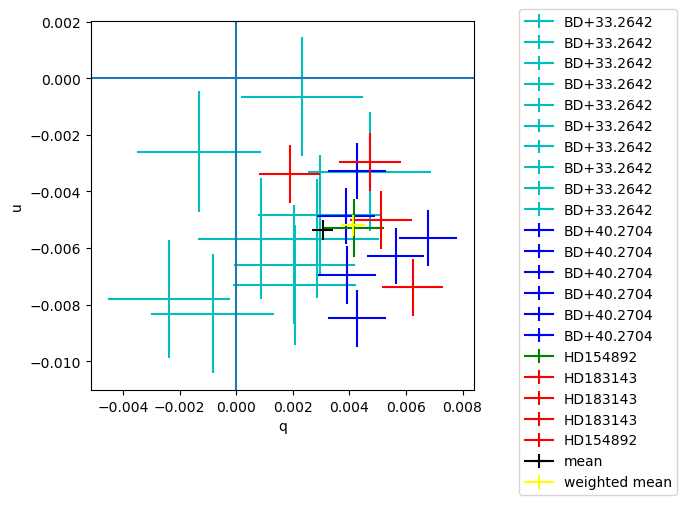

In [46]:
print("Zero-p standards")
plt.xlabel("q")
plt.ylabel("u")

# BD+33.2642
plt.errorbar(o1.q.n,o1.u.n,xerr=o1.q.s,yerr=o1.u.s,c='c',label=o1.name)
plt.errorbar(o2.q.n,o2.u.n,xerr=o2.q.s,yerr=o2.u.s,c='c',label=o2.name)
plt.errorbar(o3.q.n,o3.u.n,xerr=o3.q.s,yerr=o3.u.s,c='c',label=o3.name)
plt.errorbar(o4.q.n,o4.u.n,xerr=o4.q.s,yerr=o4.u.s,c='c',label=o4.name)
plt.errorbar(o5.q.n,o5.u.n,xerr=o5.q.s,yerr=o5.u.s,c='c',label=o5.name)
plt.errorbar(o6.q.n,o6.u.n,xerr=o6.q.s,yerr=o6.u.s,c='c',label=o6.name)
plt.errorbar(o7.q.n,o7.u.n,xerr=o7.q.s,yerr=o7.u.s,c='c',label=o7.name)
plt.errorbar(o8.q.n,o8.u.n,xerr=o8.q.s,yerr=o8.u.s,c='c',label=o8.name)
plt.errorbar(o9.q.n,o9.u.n,xerr=o9.q.s,yerr=o9.u.s,c='c',label=o9.name)
plt.errorbar(o10.q.n,o10.u.n,xerr=o10.q.s,yerr=o10.u.s,c='c',label=o10.name)

# BD+40.2704
plt.errorbar(o11.q.n,o11.u.n,xerr=o11.q.s,yerr=o11.u.s,c='b',label=o11.name)
plt.errorbar(o12.q.n,o12.u.n,xerr=o12.q.s,yerr=o12.u.s,c='b',label=o12.name)
plt.errorbar(o13.q.n,o13.u.n,xerr=o13.q.s,yerr=o13.u.s,c='b',label=o13.name)
plt.errorbar(o14.q.n,o14.u.n,xerr=o14.q.s,yerr=o14.u.s,c='b',label=o14.name)
plt.errorbar(o16.q.n,o16.u.n,xerr=o16.q.s,yerr=o16.u.s,c='b',label=o16.name)
plt.errorbar(o17.q.n,o17.u.n,xerr=o17.q.s,yerr=o17.u.s,c='b',label=o17.name)

# HD154892
plt.errorbar(o18.q.n,o18.u.n,xerr=o18.q.s,yerr=o18.u.s,c='g',label=o18.name)
plt.errorbar(o19.q.n,o19.u.n,xerr=o19.q.s,yerr=o19.u.s,c='r',label=o23.name)
plt.errorbar(o20.q.n,o20.u.n,xerr=o20.q.s,yerr=o20.u.s,c='r',label=o24.name)
plt.errorbar(o21.q.n,o21.u.n,xerr=o21.q.s,yerr=o21.u.s,c='r',label=o25.name)
plt.errorbar(o22.q.n,o22.u.n,xerr=o22.q.s,yerr=o22.u.s,c='r',label=o22.name)


qs_z = np.array([o1.q,o2.q,o3.q,o4.q,o5.q,o6.q,o7.q,o8.q,o9.q,o10.q,o11.q,
                o12.q,o13.q,o14.q,o16.q,o17.q,o18.q,o19.q,o20.q,o21.q,o22.q])
q_z = qs_z.mean()

us_z = np.array([o1.u,o2.u,o3.u,o4.u,o5.u,o6.u,o7.u,o8.u,o9.u,o10.u,o11.u,
                o12.u,o13.u,o14.u,o16.u,o17.u,o18.u,o19.u,o20.u,o21.u,o22.u])

u_z = us_z.mean()



All_Q    = [o1.q.n,o2.q.n,o3.q.n,o4.q.n,o5.q.n,o6.q.n,o7.q.n,o8.q.n,o9.q.n,o10.q.n,o11.q.n,
            o12.q.n,o13.q.n,o14.q.n,o16.q.n,o17.q.n,o18.q.n,o19.q.n,o20.q.n,o21.q.n,o22.q.n,
            o23.q.n,o24.q.n,o25.q.n,o26.q.n,o27.q.n]
All_Qerr = [o1.q.s,o2.q.s,o3.q.s,o4.q.s,o5.q.s,o6.q.s,o7.q.s,o8.q.s,o9.q.s,o10.q.s,o11.q.s,
            o12.q.s,o13.q.s,o14.q.s,o16.q.s,o17.q.s,o18.q.s,o19.q.s,o20.q.s,o21.q.s,o22.q.s,
            o23.q.s,o24.q.s,o25.q.s,o26.q.s,o27.q.s]
All_U    = [o1.u.n,o2.u.n,o3.u.n,o4.u.n,o5.u.n,o6.u.n,o7.u.n,o8.u.n,o9.u.n,o10.u.n,o11.u.n,
            o12.u.n,o13.u.n,o14.u.n,o16.u.n,o17.u.n,o18.u.n,o19.u.n,o20.u.n,o21.u.n,o22.u.n,
            o23.u.n,o24.u.n,o25.u.n,o26.u.n,o27.u.n]
All_Uerr = [o1.u.s,o2.u.s,o3.u.s,o4.u.s,o5.u.s,o6.u.s,o7.u.s,o8.u.s,o9.u.s,o10.u.s,o11.u.s,
            o12.u.s,o13.u.s,o14.u.s,o16.u.s,o17.u.s,o18.u.s,o19.u.s,o20.u.s,o21.u.s,o22.u.s,
            o23.u.s,o24.u.s,o25.u.s,o26.u.s,o27.u.s]


q_res = stats.sigma_clipped_stats(All_Q, sigma=2.8) # returns (mean, median, stddev)
q_std_st = q_res[2]
u_res = stats.sigma_clipped_stats(All_U, sigma=2.8) # returns (mean, median, stddev)
u_std_st = u_res[2]

mean_Q = np.average(All_Q,weights=list(map(lambda x: 1.0/x**2, All_Qerr)))
mean_U = np.average(All_U,weights=list(map(lambda x: 1.0/x**2, All_Uerr)))
std_Q = np.std(All_Q)/np.sqrt(len(All_Q))
std_U = np.std(All_U)/np.sqrt(len(All_U))

plt.errorbar(q_z.n,u_z.n,xerr=q_z.s,yerr=u_z.s,c='k',label='mean')
plt.errorbar(mean_Q,mean_U,xerr=std_Q,yerr=std_U,c='yellow',label='weighted mean')

# replacing mean estimates by weighted mean
q_z = ufloat(mean_Q,std_Q)
u_z = ufloat(mean_U,std_U)

print("Std of q and u:")
print(np.std(All_Q), np.std(All_U))

print( "Instumental q and u are:")
print( q_z, u_z )

plt.axvline(0)
plt.axhline(0)
plt.gca().set_aspect(1)
plt.legend(bbox_to_anchor=(1.1, 1.05))

In [47]:
dPA = ufloat(0.91,0.31)
print('Instument rotations is ',dPA,' degrees')
print('It is derived from the R-band and fixed')

Instument rotations is  0.91+/-0.31  degrees
It is derived from the R-band and fixed


Now we will correct Mkn 421 for the instumental polarization and rotate the reference frame by the opposite angle

In [48]:
mark = [s1,s2,s3]
for o in mark:
    o.correctInst(q_z,u_z)
    o.correctRot(-dPA)

In [49]:
fout = open('Mark_i_corr.dat','w')
fout.write("#JD PD[%] sPD EPVA[deg] sEVPA q sq u su\n")
for o in mark:
    out_str = "{:10.5f}".format(o.JD) + "  "
    out_str += "{:7.3f}".format(round(o.getP().n*100, 3))
    out_str += "{:7.3f}".format(round(o.getP().s*100, 3))
    out_str += "{:8.3f}".format(round(o.getPA().n, 2))
    out_str += "{:8.3f}".format(round(o.getPA().s, 2))
    out_str += "{:10.5f}".format(round(o.q.n, 5))
    out_str += "{:10.5f}".format(round(o.q.s, 5))
    out_str += "{:10.5f}".format(round(o.u.n, 5))
    out_str += "{:10.5f}".format(round(o.u.s, 5))
    out_str += "\n"
    fout.write(out_str)
fout.close()